**Movie Rating Prediction with Python**

Movie Rating Prediction is a Machine learning regression project that predicts the IMDb rating of Indian Movies based on various features such as genre ,director,actors,duration.year release and number of votes.

This project demonstrates the complete data science workflow including:
* Data preprocessing
* Feature  engineering
* Model building
* Model evaluation
* Prediction on new data



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [ ]:
df = pd.read_csv('/content/IMDb Movies India.csv',encoding='latin1')

In [ ]:
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [ ]:
df.shape

(15509, 10)

In [ ]:
df.columns

Index(['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director',
       'Actor 1', 'Actor 2', 'Actor 3'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


In [ ]:
df.isnull().sum()

,0
Name,0
Year,528
Duration,8269
Genre,1877
Rating,7590
Votes,7589
Director,525
Actor 1,1617
Actor 2,2384
Actor 3,3144


<Axes: xlabel='Rating', ylabel='Count'>

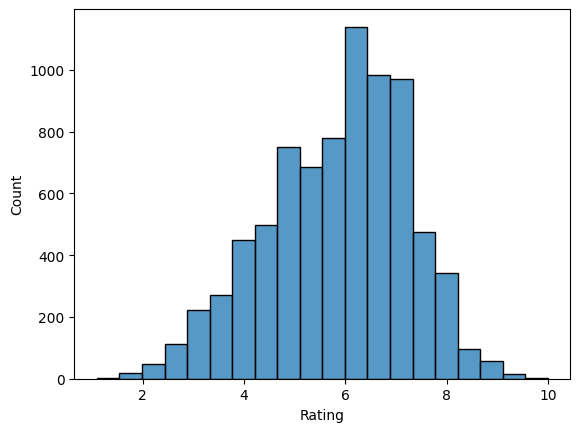

In [ ]:
sns.histplot(df['Rating'],bins = 20)

In [ ]:
df['Rating'].skew()

np.float64(-0.345551925659791)

In [ ]:
df.drop_duplicates(inplace= True)

In [ ]:
df = df.dropna(subset=['Rating'])
df.fillna('Unknown',inplace = True)

In [ ]:
df['Genre'] = df['Genre'].apply(lambda x: x.split(',') if isinstance(x, str) else x)

In [ ]:
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,[Drama],7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
3,#Yaaram,(2019),110 min,"[Comedy, Romance]",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
5,...Aur Pyaar Ho Gaya,(1997),147 min,"[Comedy, Drama, Musical]",4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor
6,...Yahaan,(2005),142 min,"[Drama, Romance, War]",7.4,"1,086",Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma
8,?: A Question Mark,(2012),82 min,"[Horror, Mystery, Thriller]",5.6,326,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia


In [ ]:
mlb = MultiLabelBinarizer()
genre_encoded = pd.DataFrame(mlb.fit_transform(df['Genre']), columns = mlb.classes_, index=df.index)

In [ ]:
df['Actors'] = df['Actor 1'] + ',' + df['Actor 2'] + ',' + df['Actor 3']
df['Actors'] = df['Actors'].apply(lambda x: x.split(','))

In [ ]:
top_actors = df['Actors'].explode().value_counts().head(30).index
df['Top_Actors'] = df['Actors'].apply(lambda x: [actor for actor in x if actor in top_actors])


In [ ]:
mlb = MultiLabelBinarizer()
actor_encoded = pd.DataFrame(mlb.fit_transform(df['Actors']), columns = mlb.classes_, index=df.index)

In [ ]:
top_directors = df['Director'].value_counts().head(20).index
df['Director'] = df['Director'].apply(
    lambda x: x if x in top_directors else 'Other'

)

director_encoded = pd.get_dummies(df['Director'],prefix = 'Dir')


In [ ]:
X = pd.concat([genre_encoded,actor_encoded,director_encoded],axis = 1)
y = df['Rating']

In [ ]:
df = df.reset_index(drop=True)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
accuracy = lr.score(X_test, y_test)

In [ ]:
precision = lr.score(X_train, y_train)

In [ ]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_estimators=200, random_state=42)

In [ ]:
y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)

In [ ]:
def evaluate(name, y_test, y_pred):
    print(f"{name}")
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("R2 Score:", r2_score(y_test, y_pred))
    print("-"*30)

evaluate("Linear Regression", y_test, y_pred_lr)
evaluate("Random Forest", y_test, y_pred_rf)

Linear Regression
MAE: 1.1202565404805804
MSE: 2.1864985682751676
R2 Score: -0.17607739195633498
------------------------------
Random Forest
MAE: 1.0060038630735446
MSE: 1.5712717467049773
R2 Score: 0.15484180747613252
------------------------------


In [ ]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10)

,0
Action,0.133376
Documentary,0.114400
Horror,0.108908
Drama,0.043435
Horror,0.026208
Drama,0.025636
Govinda,0.019484
Thriller,0.013148
Karisma Kapoor,0.011013
History,0.010896


<Axes: >

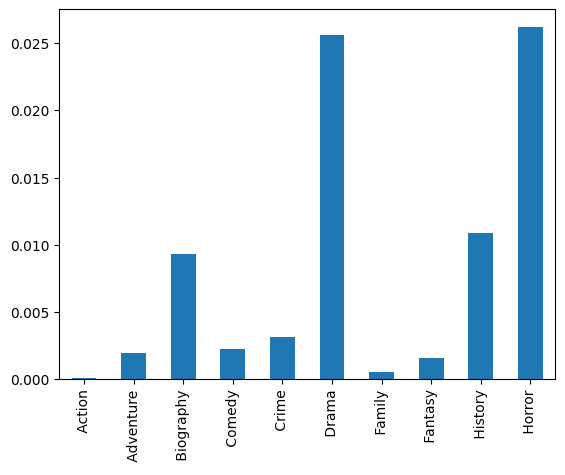

In [ ]:
importance.head(10).plot(kind='bar')

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20]
}

grid = RandomizedSearchCV(
    RandomForestRegressor(),
    params,
    cv=2,
    n_iter=2,
    n_jobs=-1,
    random_state=42
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_